In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ===============================================================
# CONFIGURACIÓN GENERAL
# ===============================================================
m = 1.0         # masa
w = 2.0         # frecuencia angular del oscilador
tmax = 10       # tiempo máximo
N = 2000        # número de puntos
t = np.linspace(0, tmax, N)

# Colores para varias trayectorias
colors = ["#1f77b4", "#d62728", "#2ca02c", "#9467bd", "#ff7f0e",
          "#17becf", "#8c564b", "#e377c2", "#7f7f7f"]

# ===============================================================
# 1) PARTÍCULA LIBRE 1D
# ===============================================================

# Conjunto de condiciones iniciales para p0:
p0_values = [-4, -3, -2, -1, 0, 1, 2, 3, 4]
x0 = 0.0

# -------------------------
# (a) ESPACIO FASE (x,p)
# -------------------------
plt.figure(figsize=(10,6))
for i, p0 in enumerate(p0_values):
    p = p0 * np.ones_like(t)
    x = x0 + (p0/m)*t
    plt.plot(x, p, lw=2, color=colors[i], label=f"$p_0={p0}$")

plt.xlabel("$x$")
plt.ylabel("$p$")
plt.title("Partícula libre — Trayectorias en el espacio fase $(x,p)$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("libre_xp.png", dpi=300)
plt.close()


# -------------------------
# (b) ESPACIO FASE EXTENDIDO (x,p,t)
# -------------------------
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection="3d")

for i, p0 in enumerate(p0_values):
    p = p0 * np.ones_like(t)
    x = x0 + (p0/m) * t
    ax.plot(x, p, t, lw=2, color=colors[i])

ax.set_xlabel("$x$")
ax.set_ylabel("$p$")
ax.set_zlabel("$t$")
ax.set_title("Partícula libre — Trayectorias en el espacio fase extendido $(x,p,t)$")
plt.tight_layout()
plt.savefig("libre_xpt.png", dpi=300)
plt.close()

# ===============================================================
# 2) OSCILADOR ARMÓNICO SIMPLE
# ===============================================================

# Conjunto de condiciones iniciales (x0,p0)
conds = [
    (1.0, 0.0),
    (0.7, 0.7),
    (0.0, 1.5),
    (-0.7, 0.9),
    (-1.2, 0.0),
    (0.5, -1.0)
]

# -------------------------
# (a) ESPACIO FASE (x,p)
# -------------------------
plt.figure(figsize=(10,6))
for i, (x0, p0) in enumerate(conds):
    x = x0*np.cos(w*t) + (p0/(m*w))*np.sin(w*t)
    p = p0*np.cos(w*t) - m*w*x0*np.sin(w*t)
    plt.plot(x, p, lw=2, color=colors[i], label=f"$(x_0,p_0)=({x0},{p0})$")

plt.xlabel("$x$")
plt.ylabel("$p$")
plt.title("Oscilador armónico — Trayectorias en el espacio fase $(x,p)$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("oscilador_xp.png", dpi=300)
plt.close()


# -------------------------
# (b) ESPACIO FASE EXTENDIDO (x,p,t)
# -------------------------
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection="3d")

for i, (x0, p0) in enumerate(conds):
    x = x0*np.cos(w*t) + (p0/(m*w))*np.sin(w*t)
    p = p0*np.cos(w*t) - m*w*x0*np.sin(w*t)
    ax.plot(x, p, t, lw=2, color=colors[i])

ax.set_xlabel("$x$")
ax.set_ylabel("$p$")
ax.set_zlabel("$t$")
ax.set_title("Oscilador armónico — Trayectorias en el espacio fase extendido $(x,p,t)$")
plt.tight_layout()
plt.savefig("oscilador_xpt.png", dpi=300)
plt.close()

print("Gráficas generadas: libre_xp.png, libre_xpt.png, oscilador_xp.png, oscilador_xpt.png")


Gráficas generadas: libre_xp.png, libre_xpt.png, oscilador_xp.png, oscilador_xpt.png


Figura guardada como: oscilador_isotropo_xy.png


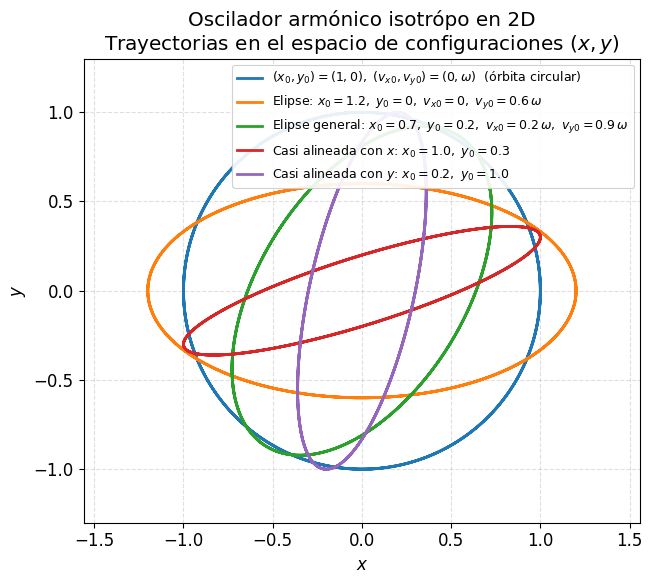

In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Oscilador armónico isotrópo en 2D
Trayectorias en el espacio de configuraciones (x, y)
Problema 4.4 – Mecánica Teórica
"""

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass


# =======================
#  Parámetros físicos
# =======================

m = 1.0          # masa (puedes cambiarla si quieres)
omega = 1.0      # frecuencia angular del oscilador
T = 2.0 * np.pi / omega   # periodo fundamental

# Tiempo para varias oscilaciones
n_periodos = 3.0
t_min = 0.0
t_max = n_periodos * T
n_puntos = 2000
t = np.linspace(t_min, t_max, n_puntos)


# =======================
#  Condiciones iniciales
# =======================

@dataclass
class CondicionInicial:
    x0: float
    y0: float
    vx0: float
    vy0: float
    label: str


# Algunos casos representativos:
# 1) Órbita circular
# 2) Elipse "aplastada" en x
# 3) Elipse general con fase distinta
# 4) Oscilación casi alineada con el eje x
# 5) Oscilación casi alineada con el eje y
condiciones = [
    CondicionInicial(
        x0=1.0, y0=0.0,
        vx0=0.0, vy0=omega,
        label=r"$(x_0,y_0)=(1,0),\ (v_{x0},v_{y0})=(0,\omega)$  (órbita circular)"
    ),
    CondicionInicial(
        x0=1.2, y0=0.0,
        vx0=0.0, vy0=0.6 * omega,
        label=r"Elipse: $x_0=1.2,\ y_0=0,\ v_{x0}=0,\ v_{y0}=0.6\,\omega$"
    ),
    CondicionInicial(
        x0=0.7, y0=0.2,
        vx0=0.2 * omega, vy0=0.9 * omega,
        label=r"Elipse general: $x_0=0.7,\ y_0=0.2,\ v_{x0}=0.2\,\omega,\ v_{y0}=0.9\,\omega$"
    ),
    CondicionInicial(
        x0=1.0, y0=0.3,
        vx0=0.0, vy0=0.2 * omega,
        label=r"Casi alineada con $x$: $x_0=1.0,\ y_0=0.3$"
    ),
    CondicionInicial(
        x0=0.2, y0=1.0,
        vx0=-0.3 * omega, vy0=0.0,
        label=r"Casi alineada con $y$: $x_0=0.2,\ y_0=1.0$"
    ),
]


# =======================
#  Soluciones analíticas
# =======================

def solucion_xy(t, ci: CondicionInicial, omega: float):
    """
    Devuelve x(t), y(t) para una condición inicial dada.

    x(t) = x0 cos(ω t) + (vx0/ω) sin(ω t)
    y(t) = y0 cos(ω t) + (vy0/ω) sin(ω t)
    """
    x = ci.x0 * np.cos(omega * t) + (ci.vx0 / omega) * np.sin(omega * t)
    y = ci.y0 * np.cos(omega * t) + (ci.vy0 / omega) * np.sin(omega * t)
    return x, y


# =======================
#  Figura principal (x,y)
# =======================

plt.rcParams.update({
    "text.usetex": False,          # pon True si tienes LaTeX instalado
    "font.size": 12,
})

fig, ax = plt.subplots(figsize=(8, 6))

for ci in condiciones:
    x, y = solucion_xy(t, ci, omega)
    ax.plot(x, y, linewidth=2, label=ci.label)

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_title(
    "Oscilador armónico isotrópo en 2D\n"
    "Trayectorias en el espacio de configuraciones $(x,y)$"
)

ax.grid(True, linestyle="--", alpha=0.4)
ax.set_aspect("equal", adjustable="box")

# Ajuste automático de límites con un pequeño margen
x_all = []
y_all = []
for ci in condiciones:
    x, y = solucion_xy(t, ci, omega)
    x_all.append(x)
    y_all.append(y)
x_all = np.concatenate(x_all)
y_all = np.concatenate(y_all)

margin = 0.15
x_min, x_max = x_all.min(), x_all.max()
y_min, y_max = y_all.min(), y_all.max()
dx = x_max - x_min
dy = y_max - y_min
ax.set_xlim(x_min - margin * dx, x_max + margin * dx)
ax.set_ylim(y_min - margin * dy, y_max + margin * dy)

legend = ax.legend(
    loc="upper right",
    frameon=True,
    framealpha=0.9,
    fontsize=9
)
legend.get_frame().set_linewidth(0.8)

fig.tight_layout()

# Guardar figura en alta resolución
nombre_figura = "oscilador_isotropo_xy.png"
fig.savefig(nombre_figura, dpi=300)
print(f"Figura guardada como: {nombre_figura}")

plt.show()


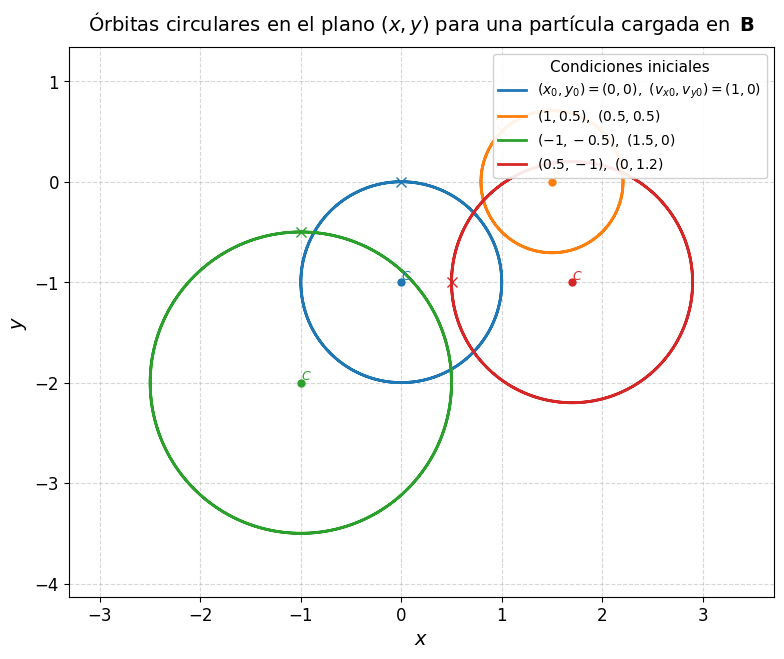

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
#   ÓRBITAS DE UNA PARTÍCULA CARGADA EN UN CAMPO MAGNÉTICO (XY)
#   H( r, p ) con frecuencia ciclotrón omega_0
# ============================================================

# Frecuencia ciclotrón (puedes cambiarla a lo que quieras)
omega0 = 1.0

# Tiempo: varios periodos para ver órbitas completas
n_periodos = 2.0
T = 2.0 * np.pi / omega0
t = np.linspace(0.0, n_periodos * T, 1000)

# ------------------------------------------------------------
# Funciones auxiliares: centro, radio y órbita (x(t), y(t))
# ------------------------------------------------------------

def centro_y_radio(x0, y0, vx0, vy0, omega0):
    """
    Dadas las condiciones iniciales (x0, y0, vx0, vy0) y la frecuencia omega0,
    calcula el centro (xc, yc) y el radio R de la órbita circular:
        xc = x0 + vy0 / omega0
        yc = y0 - vx0 / omega0
        R  = sqrt(vx0^2 + vy0^2) / omega0
    """
    xc = x0 + vy0 / omega0
    yc = y0 - vx0 / omega0
    v_perp = np.sqrt(vx0**2 + vy0**2)
    R = v_perp / omega0
    return xc, yc, R

def trayectoria_xy(t, x0, y0, vx0, vy0, omega0):
    """
    Construye x(t), y(t) a partir de:
        x(t) = xc + R cos(omega0 t + phi0)
        y(t) = yc + R sin(omega0 t + phi0)
    donde (xc, yc, R) se calculan con centro_y_radio y phi0 se fija
    para que (x(0), y(0)) = (x0, y0).
    """
    xc, yc, R = centro_y_radio(x0, y0, vx0, vy0, omega0)

    # Vector desde el centro hacia la posición inicial
    dx0 = x0 - xc
    dy0 = y0 - yc

    # Ángulo inicial phi0 tal que:
    # x0 = xc + R cos(phi0), y0 = yc + R sin(phi0)
    phi0 = np.arctan2(dy0, dx0)

    # Trayectorias
    x = xc + R * np.cos(omega0 * t + phi0)
    y = yc + R * np.sin(omega0 * t + phi0)

    return x, y, xc, yc, R

# ------------------------------------------------------------
# Lista de condiciones iniciales para varias órbitas
# (x0, y0, vx0, vy0, etiqueta)
# ------------------------------------------------------------
condiciones_iniciales = [
    # Órbita centrada cerca del origen, radio ~1
    (0.0, 0.0, 1.0, 0.0, r"$(x_0,y_0)=(0,0),\ (v_{x0},v_{y0})=(1,0)$"),

    # Órbita desplazada hacia la derecha
    (1.0, 0.5, 0.5, 0.5, r"$(1,0.5),\ (0.5,0.5)$"),

    # Órbita con centro más lejos (velocidad más grande)
    (-1.0, -0.5, 1.5, 0.0, r"$(-1,-0.5),\ (1.5,0)$"),

    # Órbita con velocidad inicialmente "vertical"
    (0.5, -1.0, 0.0, 1.2, r"$(0.5,-1),\ (0,1.2)$"),
]

# Colores para las órbitas
colores = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

# ------------------------------------------------------------
# Figura: órbitas en el plano (x, y) y sus centros
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 8))

for (x0, y0, vx0, vy0, label), color in zip(condiciones_iniciales, colores):
    x, y, xc, yc, R = trayectoria_xy(t, x0, y0, vx0, vy0, omega0)

    # Curva de la órbita
    ax.plot(x, y, lw=2.0, color=color, label=label)

    # Centro de la órbita
    ax.plot(xc, yc, marker="o", color=color, ms=5)
    ax.text(
        xc, yc,
        r"$C$",
        color=color,
        fontsize=9,
        ha="left",
        va="bottom"
    )

    # Punto inicial (x0,y0)
    ax.plot(x0, y0, marker="x", color=color, ms=7)

# Estética del gráfico
ax.set_xlabel(r"$x$", fontsize=14)
ax.set_ylabel(r"$y$", fontsize=14)
ax.set_title(
    r"Órbitas circulares en el plano $(x,y)$ para una partícula cargada en $\,\mathbf{B}$",
    fontsize=14,
    pad=12,
)
ax.grid(True, linestyle="--", alpha=0.5)
ax.set_aspect("equal", adjustable="box")

# Leyenda
leg = ax.legend(
    fontsize=10,
    loc="upper right",
    frameon=True,
    framealpha=0.9,
)
leg.set_title("Condiciones iniciales", prop={"size": 11})

# Margen extra para que no se corte nada
ax.margins(0.15)

plt.tight_layout()
plt.show()


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ===================================================
# Parámetros físicos
# ===================================================
omega0 = 1.0         # frecuencia ciclotrón ω0
n_periodos = 1.5     # cuántos periodos queremos dibujar

# Mallado temporal
T = 2.0 * np.pi / omega0
t = np.linspace(0.0, n_periodos * T, 800)

# ===================================================
# Funciones x(t), y(t) EXACTAS del libro (ec. (124))
# ===================================================
def xy_magnetico(t, x0, y0, vx0, vy0, omega0):
    """
    Implementa literalmente:

      x(t) = x0 + (vx0/ω0) sin(ω0 t) + (vy0/ω0)(1 - cos(ω0 t))
      y(t) = y0 + (vx0/ω0)(cos(ω0 t) - 1) + (vy0/ω0) sin(ω0 t)
    """
    w t = omega0 * t
    x = (x0
         + (vx0 / omega0) * np.sin(w t)
         + (vy0 / omega0) * (1.0 - np.cos(w t)))
    y = (y0
         + (vx0 / omega0) * (np.cos(w t) - 1.0)
         + (vy0 / omega0) * np.sin(w t))
    return x, y

# ===================================================
# Conjuntos de condiciones iniciales (x0, y0, vx0, vy0)
# ===================================================
# Puedes ajustar o añadir más, pero todas las trayectorias
# se generan con las fórmulas anteriores.
condiciones = [
    # (x0,  y0,  vx0, vy0, etiqueta)
    (0.0,  0.0,  1.0,  0.0,
     r"$(x_0,y_0)=(0,0),\ (v_{x0},v_{y0})=(1,0)$"),
    (1.0,  0.5,  0.5,  0.5,
     r"$(1,0.5),\ (0.5,0.5)$"),
    (-1.0, -0.5,  1.5,  0.0,
     r"$(-1,-0.5),\ (1.5,0)$"),
    (0.5, -1.0,  0.0,  1.2,
     r"$(0.5,-1),\ (0,1.2)$"),
]

# Colores para cada órbita
colores = ["C0", "C1", "C2", "C3"]

# ===================================================
# Gráfica
# ===================================================
fig, ax = plt.subplots(figsize=(7, 7))

for (x0, y0, vx0, vy0, etiqueta), color in zip(condiciones, colores):
    # Trayectoria usando SOLO x(t), y(t) del libro
    x, y = xy_magnetico(t, x0, y0, vx0, vy0, omega0)

    # Centro y radio, a partir de (125)–(126), solo para marcar
    xc = x0 + vy0 / omega0
    yc = y0 - vx0 / omega0
    R  = np.sqrt(vx0**2 + vy0**2) / omega0

    # Curva
    ax.plot(x, y, linewidth=2.0, color=color, label=etiqueta)

    # Punto inicial
    ax.scatter([x0], [y0], color=color, s=35, marker="o")

    # Centro de la órbita
    ax.scatter([xc], [yc], color=color, s=35, marker="x")

# Estética del gráfico
ax.set_xlabel(r"$x$", fontsize=14)
ax.set_ylabel(r"$y$", fontsize=14)
ax.set_title(
    r"Órbitas circulares en el plano $(x,y)$ para una partícula cargada en $\mathbf{B}$",
    fontsize=15,
    pad=12,
)
ax.set_aspect("equal", adjustable="box")
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.7)

# Leyenda
legend = ax.legend(
    title="Condiciones iniciales",
    fontsize=11,
    title_fontsize=11,
    loc="upper right",
    framealpha=0.95,
)
legend.get_frame().set_linewidth(0.8)

plt.tight_layout()
plt.show()


SyntaxError: invalid syntax (1864328972.py, line 24)

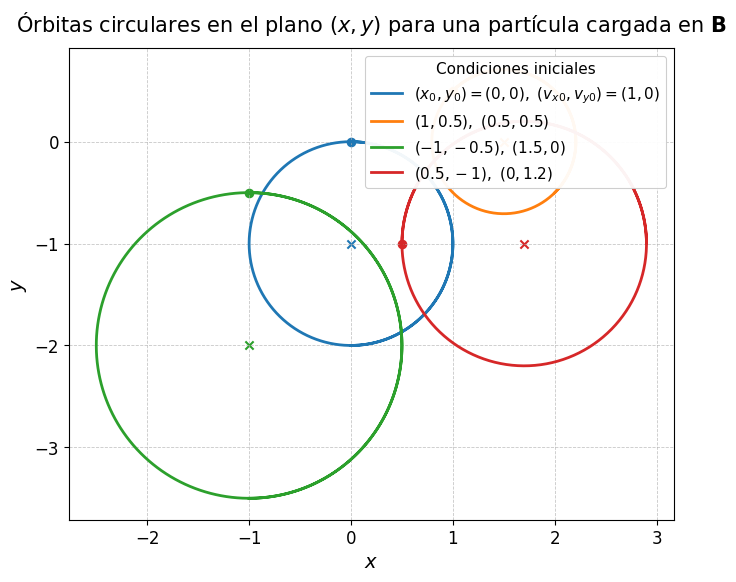

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ===================================================
# Parámetros físicos
# ===================================================
omega0 = 1.0         # frecuencia ciclotrón ω0
n_periodos = 1.5     # cuántos periodos queremos dibujar

# Mallado temporal
T = 2.0 * np.pi / omega0
t = np.linspace(0.0, n_periodos * T, 800)

# ===================================================
# Funciones x(t), y(t) EXACTAS del libro (ec. (124))
# ===================================================
def xy_magnetico(t, x0, y0, vx0, vy0, omega0):
    """
    Implementa literalmente:

      x(t) = x0 + (vx0/ω0) sin(ω0 t) + (vy0/ω0)(1 - cos(ω0 t))
      y(t) = y0 + (vx0/ω0)(cos(ω0 t) - 1) + (vy0/ω0) sin(ω0 t)
    """
    wt = omega0 * t
    x = (x0
         + (vx0 / omega0) * np.sin(wt)
         + (vy0 / omega0) * (1.0 - np.cos(wt)))
    y = (y0
         + (vx0 / omega0) * (np.cos(wt) - 1.0)
         + (vy0 / omega0) * np.sin(wt))
    return x, y

# ===================================================
# Conjuntos de condiciones iniciales (x0, y0, vx0, vy0)
# ===================================================
condiciones = [
    # (x0,  y0,  vx0, vy0, etiqueta)
    (0.0,  0.0,  1.0,  0.0,
     r"$(x_0,y_0)=(0,0),\ (v_{x0},v_{y0})=(1,0)$"),
    (1.0,  0.5,  0.5,  0.5,
     r"$(1,0.5),\ (0.5,0.5)$"),
    (-1.0, -0.5,  1.5,  0.0,
     r"$(-1,-0.5),\ (1.5,0)$"),
    (0.5, -1.0,  0.0,  1.2,
     r"$(0.5,-1),\ (0,1.2)$"),
]

colores = ["C0", "C1", "C2", "C3"]

# ===================================================
# Gráfica
# ===================================================
fig, ax = plt.subplots(figsize=(7, 7))

for (x0, y0, vx0, vy0, etiqueta), color in zip(condiciones, colores):
    # Trayectoria usando SOLO x(t), y(t) del libro
    x, y = xy_magnetico(t, x0, y0, vx0, vy0, omega0)

    # Centro y radio para marcar (125)–(126)
    xc = x0 + vy0 / omega0
    yc = y0 - vx0 / omega0
    R  = np.sqrt(vx0**2 + vy0**2) / omega0

    ax.plot(x, y, linewidth=2.0, color=color, label=etiqueta)
    ax.scatter([x0], [y0], color=color, s=35, marker="o")  # punto inicial
    ax.scatter([xc], [yc], color=color, s=35, marker="x")  # centro de la órbita

ax.set_xlabel(r"$x$", fontsize=14)
ax.set_ylabel(r"$y$", fontsize=14)
ax.set_title(
    r"Órbitas circulares en el plano $(x,y)$ para una partícula cargada en $\mathbf{B}$",
    fontsize=15,
    pad=12,
)
ax.set_aspect("equal", adjustable="box")
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.7)

legend = ax.legend(
    title="Condiciones iniciales",
    fontsize=11,
    title_fontsize=11,
    loc="upper right",
    framealpha=0.95,
)
legend.get_frame().set_linewidth(0.8)

plt.tight_layout()
plt.show()


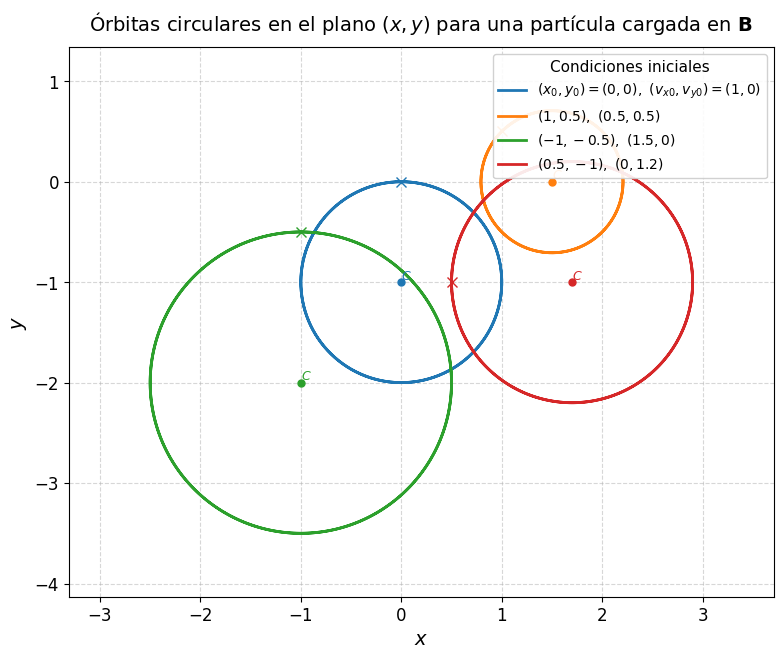

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
#   ÓRBITAS DE UNA PARTÍCULA CARGADA EN UN CAMPO MAGNÉTICO (XY)
#   H( r, p ) con frecuencia ciclotrón omega_0
# ============================================================

omega0 = 1.0

n_periodos = 2.0
T = 2.0 * np.pi / omega0
t = np.linspace(0.0, n_periodos * T, 1000)

# ------------------------------------------------------------
# Funciones auxiliares: centro, radio y órbita (x(t), y(t))
# ------------------------------------------------------------

def centro_y_radio(x0, y0, vx0, vy0, omega0):
    xc = x0 + vy0 / omega0
    yc = y0 - vx0 / omega0
    v_perp = np.sqrt(vx0**2 + vy0**2)
    R = v_perp / omega0
    return xc, yc, R

def trayectoria_xy(t, x0, y0, vx0, vy0, omega0):
    xc, yc, R = centro_y_radio(x0, y0, vx0, vy0, omega0)

    dx0 = x0 - xc
    dy0 = y0 - yc
    phi0 = np.arctan2(dy0, dx0)

    x = xc + R * np.cos(omega0 * t + phi0)
    y = yc + R * np.sin(omega0 * t + phi0)

    return x, y, xc, yc, R

# ------------------------------------------------------------
# Lista de condiciones iniciales
# ------------------------------------------------------------
condiciones_iniciales = [
    (0.0,  0.0, 1.0, 0.0,  r"$(x_0,y_0)=(0,0),\ (v_{x0},v_{y0})=(1,0)$"),
    (1.0,  0.5, 0.5, 0.5,  r"$(1,0.5),\ (0.5,0.5)$"),
    (-1.0, -0.5, 1.5, 0.0, r"$(-1,-0.5),\ (1.5,0)$"),
    (0.5, -1.0, 0.0, 1.2,  r"$(0.5,-1),\ (0,1.2)$"),
]

colores = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

# ------------------------------------------------------------
# Figura
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 8))

for (x0, y0, vx0, vy0, label), color in zip(condiciones_iniciales, colores):
    x, y, xc, yc, R = trayectoria_xy(t, x0, y0, vx0, vy0, omega0)

    ax.plot(x, y, lw=2.0, color=color, label=label)
    ax.plot(xc, yc, marker="o", color=color, ms=5)
    ax.text(xc, yc, r"$C$", color=color, fontsize=9, ha="left", va="bottom")
    ax.plot(x0, y0, marker="x", color=color, ms=7)

ax.set_xlabel(r"$x$", fontsize=14)
ax.set_ylabel(r"$y$", fontsize=14)
ax.set_title(
    r"Órbitas circulares en el plano $(x,y)$ para una partícula cargada en $\mathbf{B}$",
    fontsize=14,
    pad=12,
)
ax.grid(True, linestyle="--", alpha=0.5)
ax.set_aspect("equal", adjustable="box")

leg = ax.legend(
    fontsize=10,
    loc="upper right",
    frameon=True,
    framealpha=0.9,
)
leg.set_title("Condiciones iniciales", prop={"size": 11})

ax.margins(0.15)
plt.tight_layout()

# ========= AQUÍ SE GUARDA EL PNG =========
nombre_png = "orbitas_magnetico_xy.png"
plt.savefig(nombre_png, dpi=400, bbox_inches="tight")
# =========================================

plt.show()
